📘 UNEMPLOYMENT ANALYSIS IN INDIA (2019–2020)
# CodeAlpha Project — Data Analysis with Python

In [2]:
# 1.  Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# 2. Load Dataset
df = pd.read_csv("Unemployment in India.csv")

In [6]:
# 3.  Data Cleaning
# Clean column names
df.columns = [col.strip().replace(" ", "_").lower() for col in df.columns]

# Rename long columns
df.rename(columns={
    'estimated_unemployment_rate_(%)': 'unemployment_rate',
    'estimated_employed': 'employed',
    'estimated_labour_participation_rate_(%)': 'labour_participation_rate'
}, inplace=True)

# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Drop missing and duplicate rows
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Reorder columns
df = df[['region', 'area', 'date', 'frequency', 'unemployment_rate', 'employed', 'labour_participation_rate']]


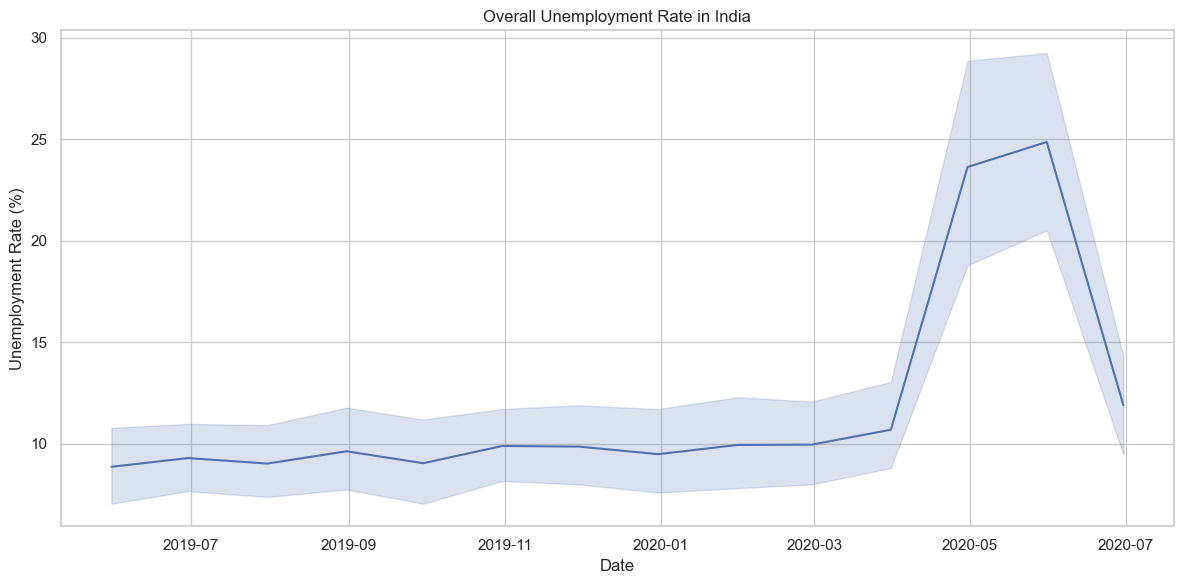

In [8]:
# 4.  Exploratory Data Analysis (EDA)

# 4.1 Overall Trend
sns.lineplot(data=df, x="date", y="unemployment_rate")
plt.title("Overall Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

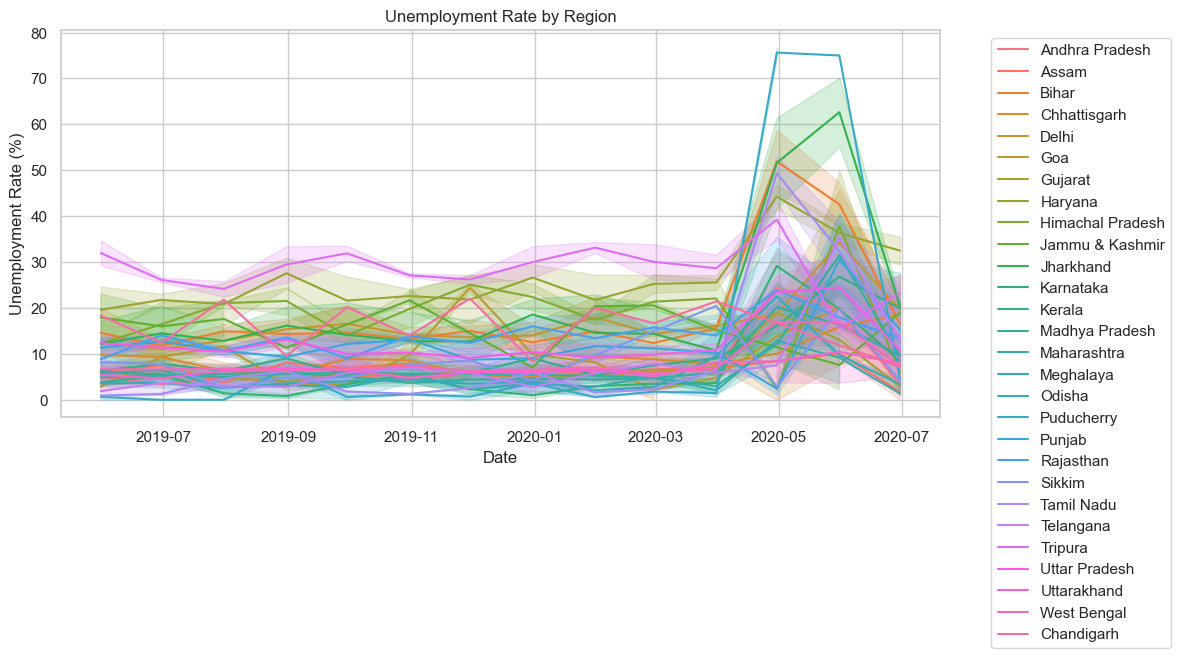

In [10]:
# 4.2 Regional Comparison

sns.lineplot(data=df, x="date", y="unemployment_rate", hue="region", linewidth=1.5)
plt.title("Unemployment Rate by Region")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

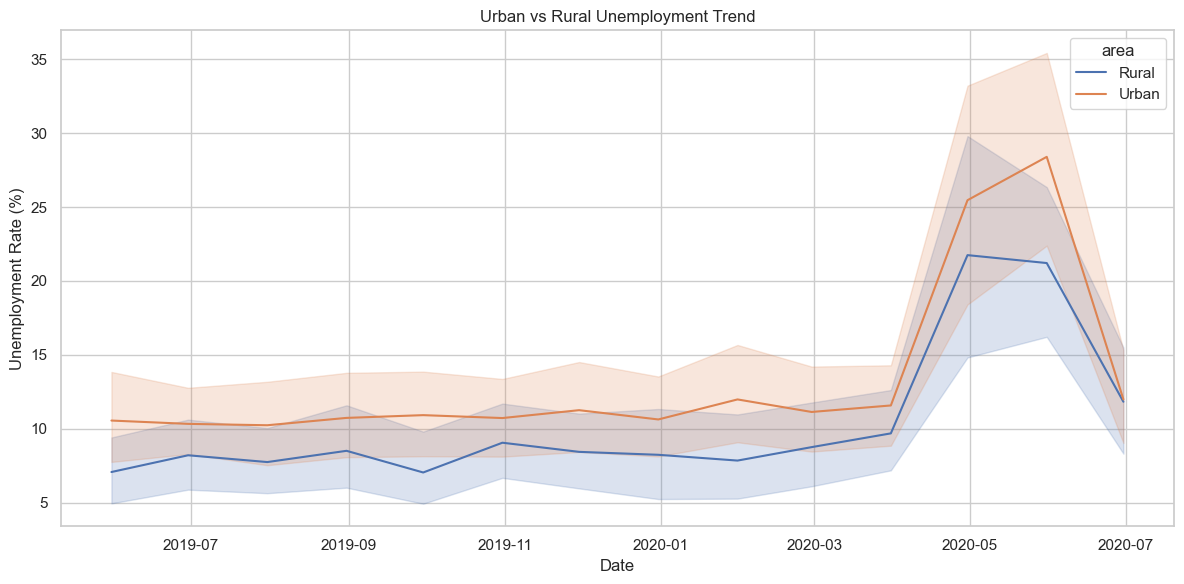

In [12]:
# 4.3 Urban vs Rural

sns.lineplot(data=df, x="date", y="unemployment_rate", hue="area")
plt.title("Urban vs Rural Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

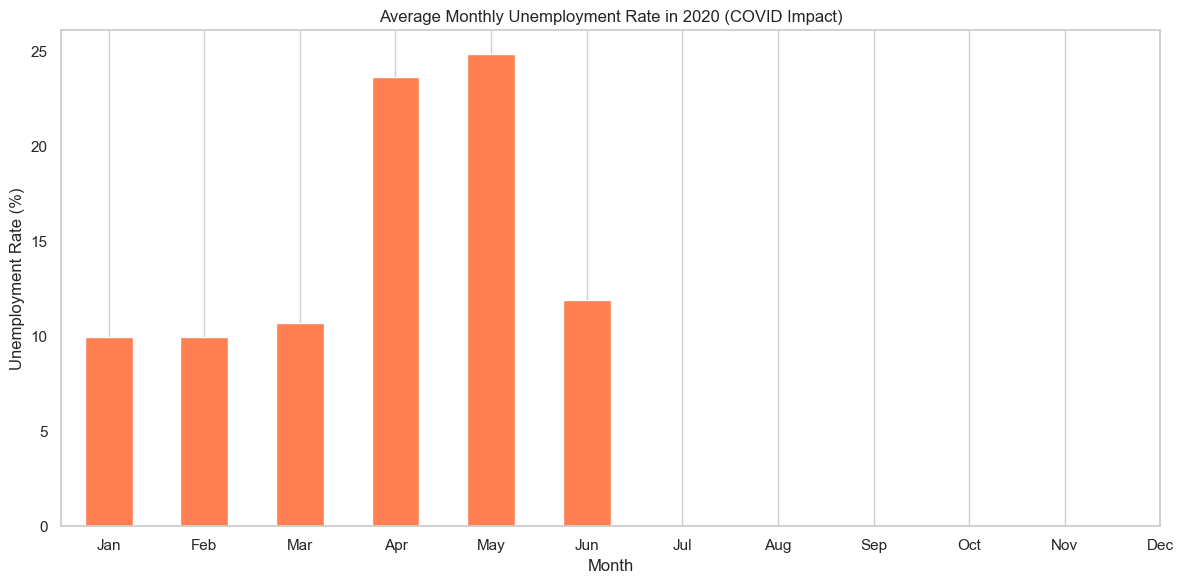

In [14]:
# 4.4 Covid-19 Monthly Impact (2020)

df_2020 = df[df['date'].dt.year == 2020].copy()
df_2020['month'] = df_2020['date'].dt.month
monthly_avg = df_2020.groupby('month')['unemployment_rate'].mean()

monthly_avg.plot(kind='bar', color='coral')
plt.title("Average Monthly Unemployment Rate in 2020 (COVID Impact)")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(ticks=range(0,12), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_6024\953863082.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = df.groupby('date')['unemployment_rate'].mean().resample('M').mean()


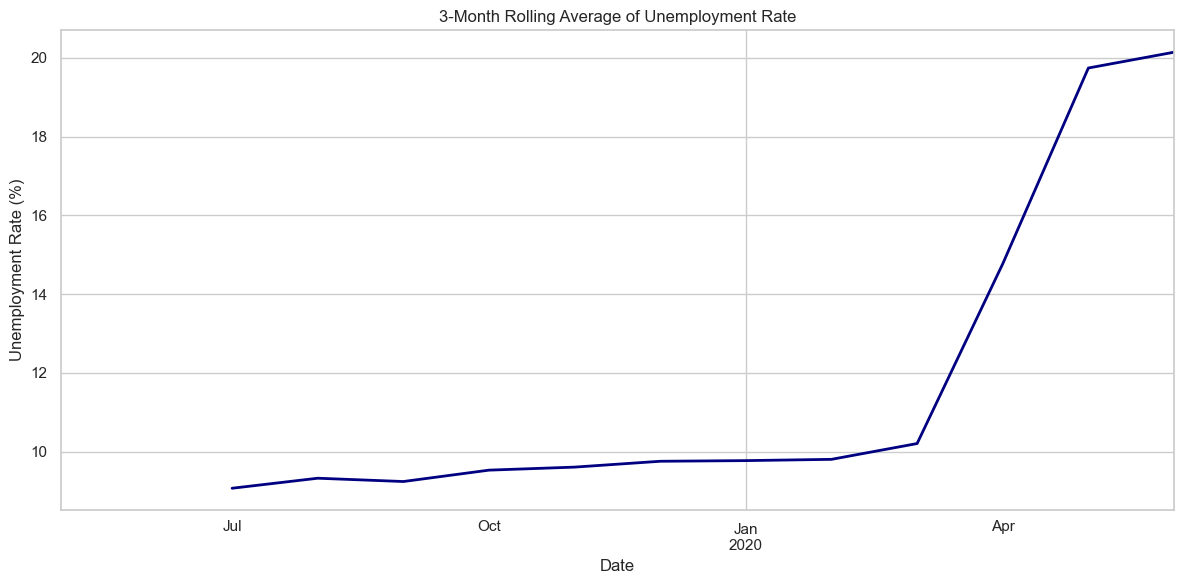

In [16]:
# 4.5 Rolling Average (Trend)

monthly_df = df.groupby('date')['unemployment_rate'].mean().resample('M').mean()
monthly_df.rolling(window=3).mean().plot(color='navy', linewidth=2)
plt.title("3-Month Rolling Average of Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
# 5. 🧠 Key Insights & Policy Recommendations

from IPython.display import Markdown

Markdown("""
### 📌 Key Insights:
- Unemployment spiked sharply in April–May 2020 due to COVID-19 lockdown.
- Urban areas faced higher and more volatile unemployment than rural areas.
- States like Delhi, Haryana, and Rajasthan were most affected.
- Labour participation dropped, showing people stopped looking for jobs.

### 🧭 Policy Suggestions:
- Launch targeted urban public job programs.
- Encourage digital reskilling for displaced workers.
- Expand rural employment schemes and digitize labour tracking.
""")


### 📌 Key Insights:
- Unemployment spiked sharply in April–May 2020 due to COVID-19 lockdown.
- Urban areas faced higher and more volatile unemployment than rural areas.
- States like Delhi, Haryana, and Rajasthan were most affected.
- Labour participation dropped, showing people stopped looking for jobs.

### 🧭 Policy Suggestions:
- Launch targeted urban public job programs.
- Encourage digital reskilling for displaced workers.
- Expand rural employment schemes and digitize labour tracking.


In [20]:
# 6. Conclusion

Markdown("""
###  Conclusion:
This analysis used Python to explore how unemployment in India evolved before and during the COVID-19 pandemic. Through visualizations and trend analysis, it revealed critical periods of job loss and recovery, helping inform strategies for resilience and employment support.

**Tools Used**: Python, Pandas, Seaborn, Matplotlib  
**Dataset**: Kaggle – Unemployment in India (2019–2020)
""")


###  Conclusion:
This analysis used Python to explore how unemployment in India evolved before and during the COVID-19 pandemic. Through visualizations and trend analysis, it revealed critical periods of job loss and recovery, helping inform strategies for resilience and employment support.

**Tools Used**: Python, Pandas, Seaborn, Matplotlib  
**Dataset**: Kaggle – Unemployment in India (2019–2020)
